In [1]:
import brainsss
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
import time
import h5py
import ants
import nibabel as nib
from scipy.ndimage import uniform_filter, gaussian_filter
import shutil
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.image import grid_to_graph
import gc
import sys
import warnings
from scipy.ndimage import gaussian_filter1d,gaussian_filter
from scipy.signal import butter, sosfiltfilt, filtfilt, freqz,iirnotch
import cv2
from scipy.ndimage.morphology import binary_erosion
from scipy.ndimage.morphology import binary_dilation
from scipy.ndimage import zoom
from sklearn.mixture import GaussianMixture
import scipy.stats as stats
import sklearn
import pickle
import itertools
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import pandas as pd
from skimage import measure
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.ndimage.morphology import binary_erosion, binary_dilation
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist
import csv
from functools import reduce
from sklearn.decomposition import PCA

In [2]:
color_map_color_1=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7','#FFFFFF','#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
cmap_personal = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', color_map_color_1)

In [3]:
home_path = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/'
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'
cluster_dir = os.path.join(later_dir, 'clustering')
save_dir=os.path.join(later_dir,'figs')
# Suppress RuntimeWarning
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [61]:
event1='fixed_best_final'
# event2='best'
n_clusters=500
label_files=[]
cluster_files=[]
for file in os.listdir(cluster_dir):
#     print(file)
    if f'_{n_clusters}' in file and 'labels' in file and 'total' in file:
        label_files.append(file)
    elif f'_{n_clusters}_' in file and 'clusters' in file and event1 in file:
        cluster_files.append(file)

## Load supervox

In [62]:
cluster_files

['superclust_clusters_500_fixed_best_final.pkl']

In [63]:
%%time
best_cluster_path_5sec=os.path.join(cluster_dir,cluster_files[0])
# best_cluster_path=os.path.join(cluster_dir,cluster_files[1])
print(best_cluster_path_5sec)
with open(best_cluster_path_5sec, 'rb') as file:
    five_sec = pickle.load(file)
    print(five_sec.keys())

# with open(best_cluster_path, 'rb') as file:
#     best = pickle.load(file)
#     print(best.keys())
    

/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/clustering/superclust_clusters_500_fixed_best_final.pkl
dict_keys(['total', 'inc', 'dec', 'flat', 'non'])
CPU times: user 1.24 ms, sys: 1.17 ms, total: 2.4 ms
Wall time: 50 ms


In [64]:
label_files

['supercluster_labels_total_500.npy']

In [65]:
%%time
best_label_path=os.path.join(cluster_dir,label_files[0])
print(best_label_path)
giant_total_labels=np.load(best_label_path)
print(giant_total_labels.shape)

/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/clustering/supercluster_labels_total_500.npy
(4171804,)
CPU times: user 2 ms, sys: 15 ms, total: 17 ms
Wall time: 16.9 ms


In [66]:
giant_total_anat=giant_total_labels.reshape(314,146,91)


In [67]:
rainbow_color=np.asarray(['#FFFFFF','#EF476F', '#F78C6B', '#FFD166', '#06D6A0','#118AB2','#6A4C93','#6d0d25']) #,  '#6d0d25'
# cmap_rainbow = matplotlib.colors.LinearSegmentedColormap.from_list(
#     'cmap', rainbow_color)
cmap_rainbow = matplotlib.colors.ListedColormap(rainbow_color)

In [68]:
giant_total_anat.shape

(314, 146, 91)

(-0.5, 313.5, 145.5, -0.5)

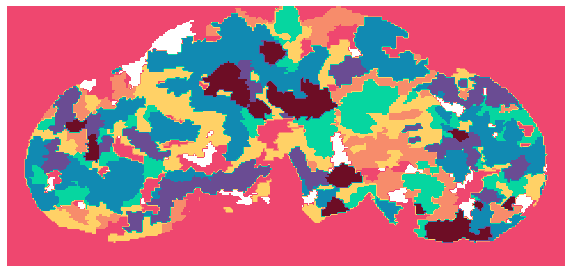

In [69]:
z=45
fig,ax=plt.subplots(figsize=(10,10))
ax.imshow(np.nanmax(giant_total_anat[...,30:34],axis=-1).T, cmap=cmap_rainbow)
plt.axis('off')
# plt.savefig(os.path.join(save_dir,f'superclust_ex.png'), dpi=300, bbox_inches='tight')

In [70]:
fixed = brainsss.load_fda_meanbrain()
behaviors=list(five_sec.keys())

In [71]:
five_sec['inc'].shape

(500, 50)

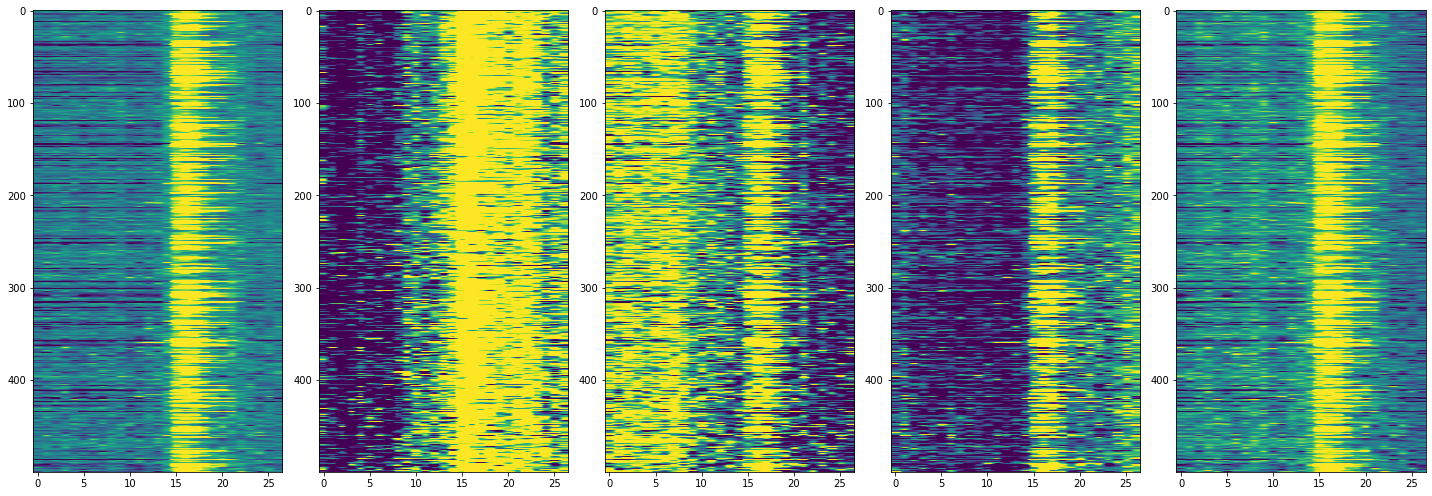

In [72]:
# ax_ap=0.1
# superclust_dict=best
# fig,axs=plt.subplots(1,3,figsize=(10,10))
# axs[0].imshow(superclust_dict['inc'], vmax=0.01,vmin=-0.01)
# axs[0].set_aspect(ax_ap)
# axs[1].imshow(superclust_dict['dec'],  vmax=0.01,vmin=-0.01)
# axs[1].set_aspect(ax_ap)
# axs[2].imshow(superclust_dict['flat'],  vmax=0.01,vmin=-0.01)
# axs[2].set_aspect(ax_ap)
# plt.tight_layout()

ax_ap=0.1
start=15
end=40
superclust_dict=five_sec
fig,axs=plt.subplots(1,len(behaviors),figsize=(20,10))
for i,behave in enumerate(behaviors):
    axs[i].imshow(superclust_dict[behave][:,14:41], vmax=0.01,vmin=-0.01)
    axs[i].set_aspect(ax_ap)
plt.tight_layout()

In [75]:
superclust_dict_trim={}
for behavior in five_sec:
#     print(behavior)
    signals_total=five_sec[behavior][:,14:41]
    superclust_dict_trim[behavior]=signals_total
    
superclust_dict_z={}
for behavior in five_sec:
    print(behavior)
    signals_total_z=scipy.stats.zscore(five_sec[behavior],axis=1)
    superclust_dict_z[behavior]=signals_total_z

total
inc
dec
flat
non


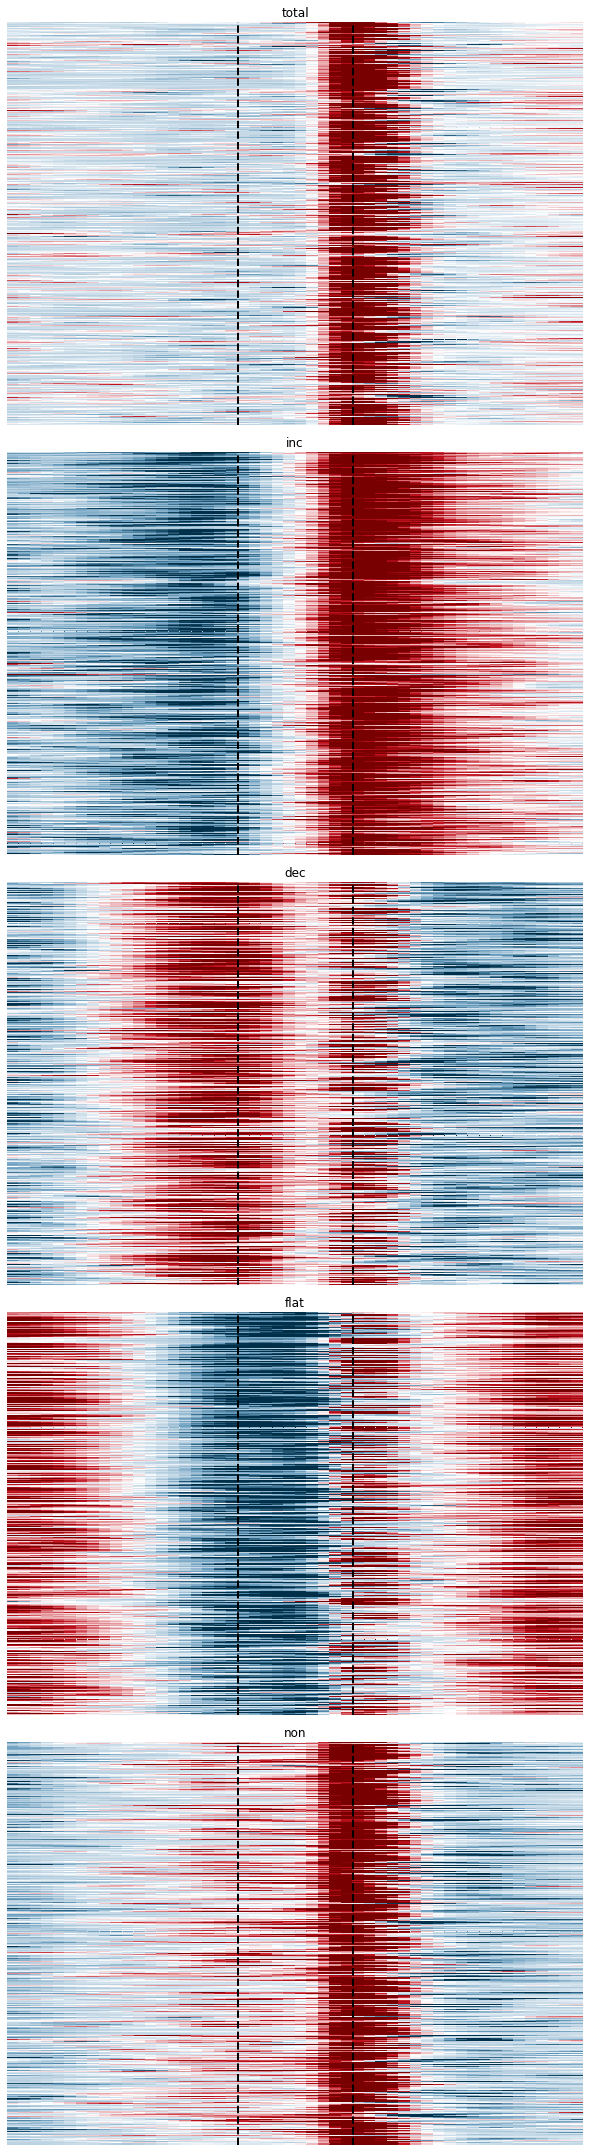

In [79]:
ax_ap=0.07
vmax=1
vmin=-1
plot_dict=superclust_dict_z
fig,axs=plt.subplots(len(behaviors),1,figsize=(20,30))
for i,b in enumerate(behaviors):
    sns.heatmap(gaussian_filter1d(plot_dict[b],sigma=2), cmap=cmap_personal, ax=axs[i], square=False,  
                center=0, vmax=vmax, vmin=vmin,yticklabels=False,xticklabels=False, cbar=False)
    axs[i].set_aspect(ax_ap)
    axs[i].axvline(x=20, ymin=0, ymax=1, ls='--', color='k', lw=2)
    axs[i].axvline(x=30, ymin=0, ymax=1, ls='--', color='k', lw=2)
    axs[i].set_title(b)
plt.tight_layout()

In [17]:
roi_atlas = brainsss.load_roi_atlas()

explosion_rois = brainsss.load_explosion_groups()
all_rois = brainsss.unnest_roi_groups(explosion_rois)
roi_masks = brainsss.make_single_roi_masks(all_rois, roi_atlas)
roi_contours = brainsss.make_single_roi_contours(roi_masks, roi_atlas)

In [18]:
full_res=[]
be=behaviors[0]
n_clusters=500
cluster_brain=plot_dict[be]
brain=cluster_brain.T
cluster_labels=giant_total_labels.T
n_tp = brain.shape[0]
n_clusters = brain.shape[1]
brain_dims=[314,146,91]

colored_by_betas = np.zeros((n_tp, brain_dims[0]*brain_dims[1]*brain_dims[2]))
colored_by_betas = brain[:, cluster_labels]  # Shape: (n_tp, n_voxels)
colored_by_betas = colored_by_betas.reshape(n_tp, brain_dims[0], brain_dims[1], brain_dims[2])
#     for cluster_num in range(n_clusters):
#         cluster_mask = cluster_labels==cluster_num
# #         print(np.shape(cluster_mask))
#         colored_by_betas[:,cluster_mask] = brain[:,cluster_num,np.newaxis]
colored_by_betas = colored_by_betas.reshape(n_tp,brain_dims[0],brain_dims[1],brain_dims[2])
full_res=np.asarray(colored_by_betas)

In [19]:
np.shape(full_res)

(50, 314, 146, 91)

In [20]:
tp=3
brain=full_res
input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
data_to_plot = brain[tp][:,:,::-1]
vmax = 3 #this was 0.5 for STA <------------
explosion_map = brainsss.place_roi_groups_on_canvas(explosion_rois,
                                                    roi_masks,
                                                    roi_contours,
                                                    data_to_plot,
                                                    input_canvas,
                                                    vmax=vmax,
                                                    cmap=cmap_personal, diverging=True)#'hot')

(-0.5, 499.5, 329.5, -0.5)

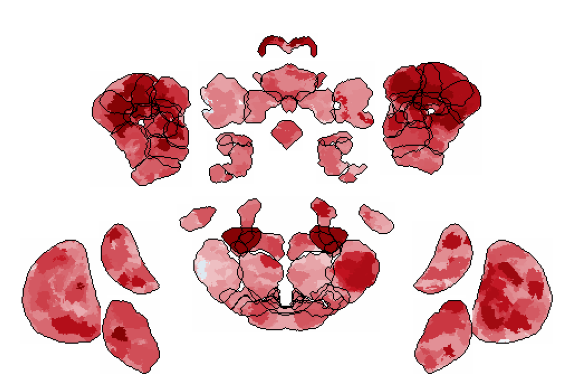

In [21]:
plt.subplots(figsize=(10,10))
plt.imshow(explosion_map[170:,:]) #this was made with cmap=hot
plt.axis('off')
# plt.savefig(os.path.join(save_dir,f'superclust_explode_{tp}_{be}_{event1}.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'superclust_explode_{tp}_{be}_{event1}.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)



In [22]:
load_file = os.path.join(cluster_dir, 'cluster_labels_best_flies.npy')
supervox_labels=np.load(load_file)
print(np.shape(supervox_labels))

(91, 45844)


In [23]:
supervox_labels=supervox_labels.reshape(91,314,146)

(-0.5, 313.5, 145.5, -0.5)

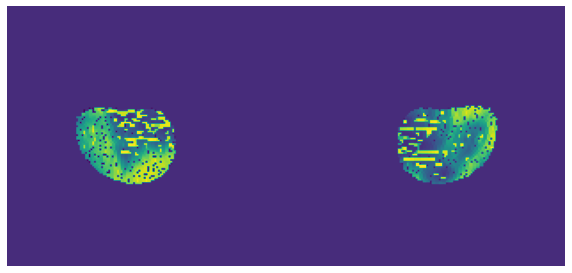

In [24]:
fig,ax=plt.subplots(figsize=(10,10))
ax.imshow(supervox_labels[1].T)
plt.axis('off')

In [25]:
load_file = os.path.join(cluster_dir, '10flies_cluster_labels_best_flies.npy')
brain_total=np.load(load_file)
print(np.shape(brain_total))
brain_total=brain_total.reshape(91,314,146)
print(np.shape(brain_total))

(91, 45844)
(91, 314, 146)


(-0.5, 313.5, 145.5, -0.5)

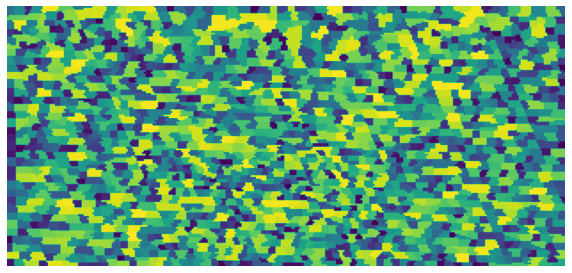

In [26]:
fig,ax=plt.subplots(figsize=(10,10))
ax.imshow(brain_total[0].T)
plt.axis('off')